# Bangalore House Price Prediction using Machine Learning

## Import Libraries

In [74]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

## Load Dataset

In [75]:
df=pd.read_csv('Bengaluru_House_Data.csv')  


## Data Understanding

In [76]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


## Data Cleaning and Preprocessing

In [78]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [79]:
df.dropna(inplace=True)

## Feature Engineering

In [80]:
df['total_sqft'].unique()


array(['1056', '2600', '1521', ..., '1919', '2111', '4689'],
      shape=(1682,), dtype=object)

In [81]:
def conversion(x):
    try:
        return float(x)
    except:
        temp=x.split('-')
        if len(temp)==2:
            return (float(temp[0])+float(temp[1]))/2
        try:
            return float(temp[0])
        except:
            return None
df['total_sqft']=df['total_sqft'].apply(conversion)
df.dropna(inplace=True)

In [82]:
area_dummies = pd.get_dummies(df['area_type'], drop_first=True)
df = pd.concat([df, area_dummies], axis=1)
df.drop('area_type', axis=1, inplace=True)

In [83]:
df['bhk']=df['size'].apply(lambda x: int(x.split(' ')[0]))
df.drop('size', axis=1, inplace=True)   

In [84]:
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)


In [85]:
location_dummies = pd.get_dummies(df['location'], drop_first=True)
df = pd.concat([df, location_dummies], axis=1)
df.drop('location', axis=1, inplace=True)


In [86]:
df = df[df['price'] < df['price'].quantile(0.99)]
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
df = df[(df['price_per_sqft'] >= 3000) & (df['price_per_sqft'] <= 15000)]
df.drop('price_per_sqft', axis=1, inplace=True)


In [87]:
df.drop('availability', axis=1, inplace=True)
df.drop('society', axis=1, inplace=True)


In [88]:
df.head()

,total_sqft,bath,balcony,price,Carpet Area,Plot Area,Super built-up Area,bhk,5th Phase JP Nagar,7th Phase JP Nagar,...,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur,other
0,1056.0,2.0,1.0,39.07,False,False,True,2,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,False,True,False,4,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,False,False,True,3,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1170.0,2.0,1.0,38.00,False,False,True,2,False,False,...,False,False,False,False,False,True,False,False,False,False
11,2785.0,5.0,3.0,295.00,False,True,False,4,False,False,...,False,False,False,False,False,True,False,False,False,False


In [89]:
print(df.columns)

Index(['total_sqft', 'bath', 'balcony', 'price', 'Carpet  Area', 'Plot  Area',
       'Super built-up  Area', 'bhk', '5th Phase JP Nagar',
       '7th Phase JP Nagar',
       ...
       'Tumkur Road', 'Uttarahalli', 'Varthur', 'Vijayanagar', 'Vittasandra',
       'Whitefield', 'Yelahanka', 'Yelahanka New Town', 'Yeshwanthpur',
       'other'],
      dtype='object', length=151)


In [90]:
X = df.drop('price', axis=1)
y = df['price']


In [91]:
df.shape

(7075, 151)

## Linear Regression Model

In [92]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train) 
pred=model.predict(x_test)
print(r2_score(y_test,pred))

0.7972304938220727


## Decision Tree Model

In [93]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)


## Random Forest Model

In [94]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

## Model Comparison

In [95]:
from sklearn.metrics import r2_score

print("Linear Regression :", r2_score(y_test, pred))
print("Decision Tree     :", r2_score(y_test, dt_pred))
print("Random Forest     :", r2_score(y_test, rf_pred))

Linear Regression : 0.7972304938220727
Decision Tree     : 0.6729880907240953
Random Forest     : 0.8116355154152761


## Model Evaluation 

In [96]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2_score(y_test, rf_pred))

MAE : 16.40355195025986
RMSE: 27.64210009315501
R² : 0.8116355154152761


## Sample Prediction 

In [97]:
sample = x_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Price:", prediction[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 47.541652308802334
Actual Price: 47.0


## Visualization

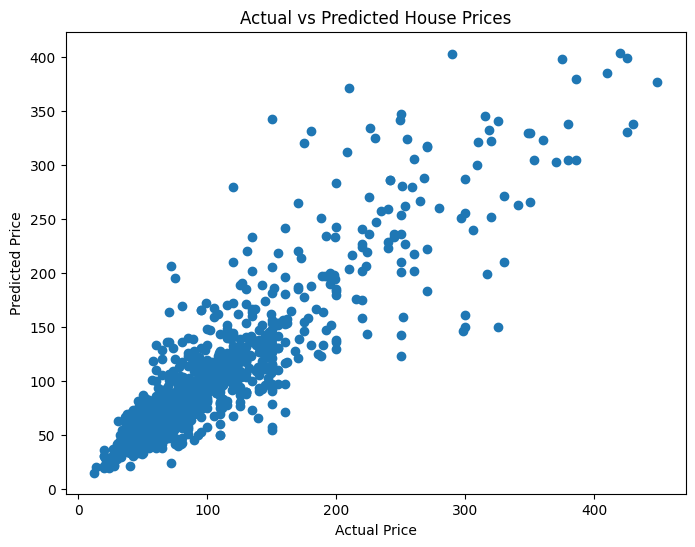

In [98]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Save Model

In [99]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

print("Random Forest Model Saved Successfully")

Random Forest Model Saved Successfully


## Conclusion

Three machine learning models were trained and evaluated for Bangalore house price prediction. Random Forest Regressor achieved the best performance with an R² score of approximately 0.81 and was selected as the final model. The trained model was saved for future deployment and real-time predictions.